In [ ]:
import json
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# Paths
DATA_ROOT = Path(r"C:\Users\Niraj Mhatre\projects\motor_insurance_data\Data\CarDD_release\CarDD_release")
COCO_DIR = DATA_ROOT / "CarDD_COCO"
ANNOTATION_DIR = COCO_DIR / "annotations"

# Load annotation file
annotation_file = ANNOTATION_DIR / "instances_train2017.json"   # replace with your filename

with open(annotation_file, "r") as file:
    data = json.load(file)

# Category dictionary
category_dict = {}

for category in data["categories"]:
    category_dict[category["id"]] = category["name"]

Data loaded successfully!


In [3]:
from collections import Counter

category_counts = Counter()

for annotation in data["annotations"]:
    category_id = annotation["category_id"]
    category_counts[category_id] += 1

for category_id, count in category_counts.items():
    print(category_dict[category_id], ":", count)

scratch : 2560
tire flat : 225
crack : 651
dent : 1806
lamp broken : 494
glass shatter : 475


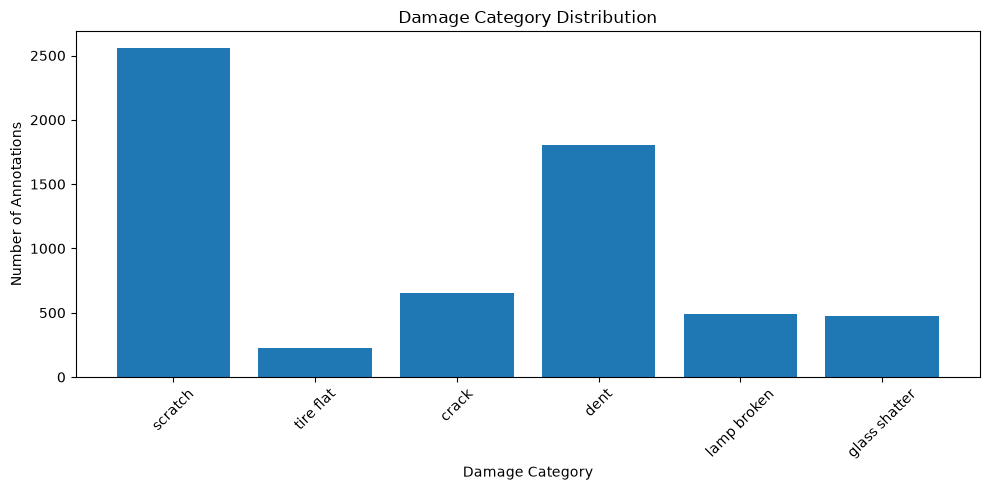

In [4]:
categories = []
counts = []

for category_id, count in category_counts.items():
    categories.append(category_dict[category_id])
    counts.append(count)

plt.figure(figsize=(10, 5))

plt.bar(categories, counts)

plt.xlabel("Damage Category")
plt.ylabel("Number of Annotations")
plt.title("Damage Category Distribution")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
damage_per_image = Counter()

for annotation in data["annotations"]:
    image_id = annotation["image_id"]
    damage_per_image[image_id] += 1

In [6]:
damage_counts = list(damage_per_image.values())

print("Number of images with annotations:", len(damage_counts))
print("Maximum damages in one image:", max(damage_counts))
print("Average damages per image:", sum(damage_counts) / len(damage_counts))

Number of images with annotations: 2816
Maximum damages in one image: 13
Average damages per image: 2.2056107954545454


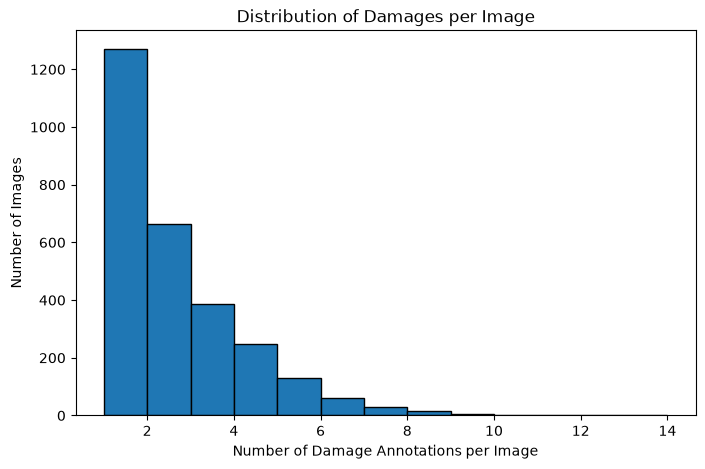

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(damage_counts, bins=range(1, max(damage_counts) + 2), edgecolor="black")

plt.xlabel("Number of Damage Annotations per Image")
plt.ylabel("Number of Images")
plt.title("Distribution of Damages per Image")

plt.show()

In [8]:
bbox_data = []

for annotation in data["annotations"]:

    image_id = annotation["image_id"]

    x, y, width, height = annotation["bbox"]

    box_area = width * height

    bbox_data.append({
        "image_id": image_id,
        "category_id": annotation["category_id"],
        "x": x,
        "y": y,
        "width": width,
        "height": height,
        "box_area": box_area
    })

In [9]:
image_dimensions = {}

for image in data["images"]:

    image_id = image["id"]

    image_dimensions[image_id] = {
        "width": image["width"],
        "height": image["height"]
    }

In [10]:
for item in bbox_data:

    image_id = item["image_id"]

    image_width = image_dimensions[image_id]["width"]
    image_height = image_dimensions[image_id]["height"]

    image_area = image_width * image_height

    item["image_area"] = image_area

    item["relative_damage_area"] = item["box_area"] / image_area

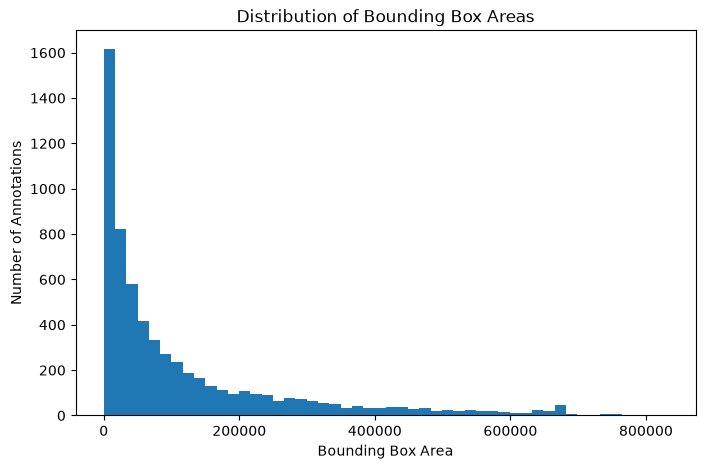

In [11]:
box_areas = [item["box_area"] for item in bbox_data]

plt.figure(figsize=(8, 5))

plt.hist(box_areas, bins=50)

plt.xlabel("Bounding Box Area")
plt.ylabel("Number of Annotations")
plt.title("Distribution of Bounding Box Areas")

plt.show()

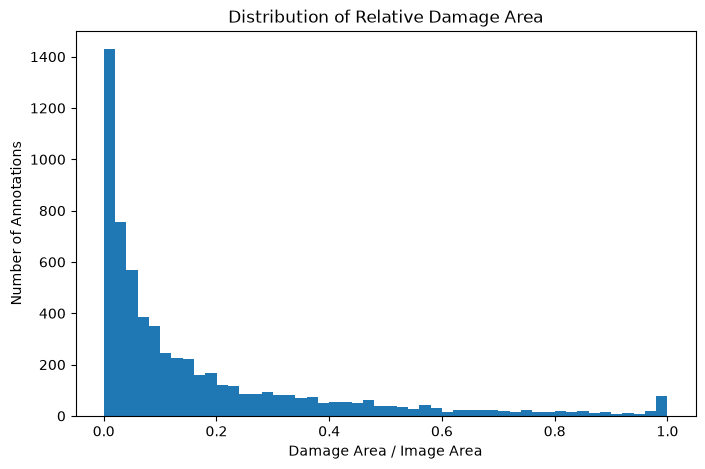

In [12]:
relative_areas = [
    item["relative_damage_area"]
    for item in bbox_data
]

plt.figure(figsize=(8, 5))

plt.hist(relative_areas, bins=50)

plt.xlabel("Damage Area / Image Area")
plt.ylabel("Number of Annotations")
plt.title("Distribution of Relative Damage Area")

plt.show()

In [13]:
print("Minimum relative damage area:", min(relative_areas))
print("Maximum relative damage area:", max(relative_areas))
print("Average relative damage area:", sum(relative_areas) / len(relative_areas))

Minimum relative damage area: 0.0001748374812593703
Maximum relative damage area: 1.0
Average relative damage area: 0.17074726548275576


In [14]:
import numpy as np

print("25th percentile:", np.percentile(relative_areas, 25))
print("50th percentile:", np.percentile(relative_areas, 50))
print("75th percentile:", np.percentile(relative_areas, 75))

25th percentile: 0.023014706331501926
50th percentile: 0.0785962495468278
75th percentile: 0.22346873775007195


In [15]:
category_area = {}

for item in bbox_data:

    category_id = item["category_id"]

    if category_id not in category_area:
        category_area[category_id] = []

    category_area[category_id].append(
        item["relative_damage_area"]
    )

In [16]:
for category_id, areas in category_area.items():

    average_area = sum(areas) / len(areas)

    print(
        category_dict[category_id],
        ":",
        average_area
    )

scratch : 0.11238970216146334
tire flat : 0.37169457456782035
crack : 0.031567717444062414
dent : 0.13589607901149459
lamp broken : 0.24026738492706204
glass shatter : 0.6410344383104799


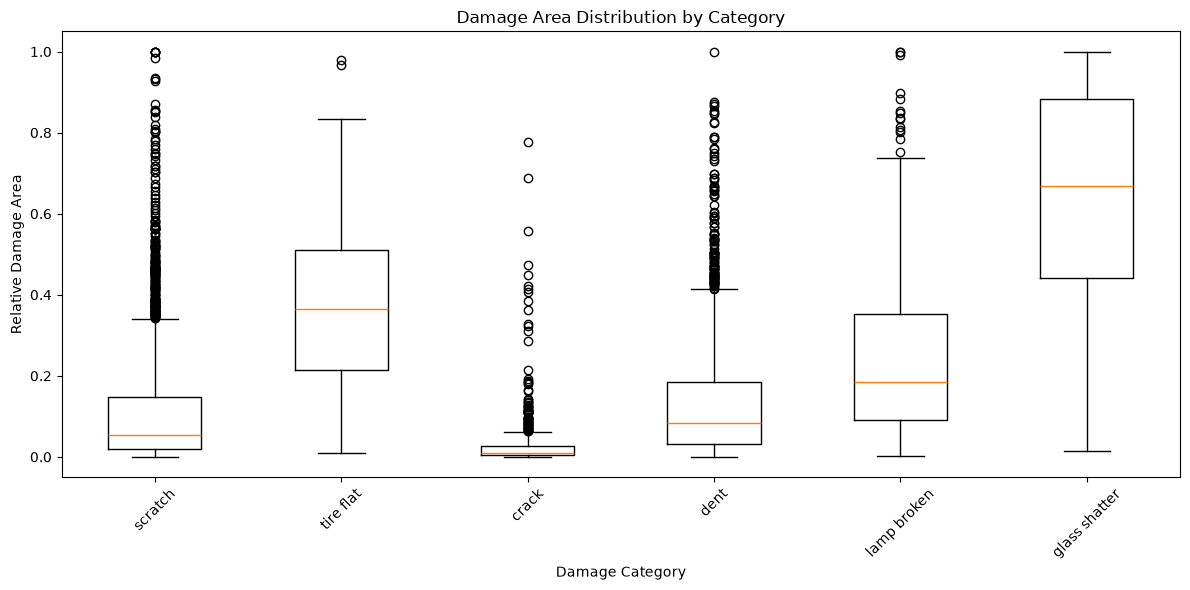

In [18]:
labels = []
area_values = []

for category_id, areas in category_area.items():

    labels.append(category_dict[category_id])
    area_values.append(areas)

plt.figure(figsize=(12, 6))

plt.boxplot(area_values, tick_labels=labels)

plt.xlabel("Damage Category")
plt.ylabel("Relative Damage Area")
plt.title("Damage Area Distribution by Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
image_dict = {}

for image in data["images"]:
    image_dict[image["id"]] = image

category_ids = set(category_dict.keys())
image_ids = set(image_dict.keys())

In [20]:
boxes_outside = []

for annotation in data["annotations"]:

    image_id = annotation["image_id"]

    if image_id not in image_dict:
        continue

    image_width = image_dict[image_id]["width"]
    image_height = image_dict[image_id]["height"]

    x, y, width, height = annotation["bbox"]

    if x < 0 or y < 0 or x + width > image_width or y + height > image_height:
        boxes_outside.append(annotation["id"])

print("Number of boxes outside image boundaries:", len(boxes_outside))
print("Annotation IDs:", boxes_outside[:20])

Number of boxes outside image boundaries: 0
Annotation IDs: []


In [21]:
missing_image_ids = []

for annotation in data["annotations"]:

    if annotation["image_id"] not in image_ids:
        missing_image_ids.append(annotation["id"])

print("Number of annotations with missing image IDs:", len(missing_image_ids))
print("Annotation IDs:", missing_image_ids[:20])

Number of annotations with missing image IDs: 0
Annotation IDs: []


In [22]:
missing_category_ids = []

for annotation in data["annotations"]:

    if annotation["category_id"] not in category_ids:
        missing_category_ids.append(annotation["id"])

print("Number of annotations with missing category IDs:", len(missing_category_ids))
print("Annotation IDs:", missing_category_ids[:20])

Number of annotations with missing category IDs: 0
Annotation IDs: []


In [23]:
annotated_image_ids = set()

for annotation in data["annotations"]:
    annotated_image_ids.add(annotation["image_id"])

images_without_annotations = image_ids - annotated_image_ids

print("Number of images without annotations:", len(images_without_annotations))
print("Image IDs:", list(images_without_annotations)[:20])

Number of images without annotations: 0
Image IDs: []


In [24]:
annotation_ids = []

for annotation in data["annotations"]:
    annotation_ids.append(annotation["id"])

duplicate_annotation_ids = []

for annotation_id, count in Counter(annotation_ids).items():

    if count > 1:
        duplicate_annotation_ids.append(annotation_id)

print("Number of duplicate annotation IDs:", len(duplicate_annotation_ids))
print("Duplicate IDs:", duplicate_annotation_ids[:20])

Number of duplicate annotation IDs: 0
Duplicate IDs: []


In [25]:
category_counts = Counter()

for annotation in data["annotations"]:
    category_counts[annotation["category_id"]] += 1

total_annotations = len(data["annotations"])

class_proportions = {}

for category_id, count in category_counts.items():

    class_proportions[category_id] = count / total_annotations

    print(
        category_dict[category_id],
        "->",
        round(class_proportions[category_id], 4)
    )

scratch -> 0.4122
tire flat -> 0.0362
crack -> 0.1048
dent -> 0.2908
lamp broken -> 0.0795
glass shatter -> 0.0765


In [26]:
relative_damage_areas = []

for annotation in data["annotations"]:

    image_id = annotation["image_id"]

    if image_id not in image_dict:
        continue

    image_width = image_dict[image_id]["width"]
    image_height = image_dict[image_id]["height"]

    image_area = image_width * image_height

    x, y, width, height = annotation["bbox"]

    box_area = width * height

    relative_area = box_area / image_area

    relative_damage_areas.append(relative_area)

In [27]:
print("Mean relative damage area:",
      sum(relative_damage_areas) / len(relative_damage_areas))

print("Minimum:",
      min(relative_damage_areas))

print("Maximum:",
      max(relative_damage_areas))

print("25th percentile:",
      np.percentile(relative_damage_areas, 25))

print("Median:",
      np.percentile(relative_damage_areas, 50))

print("75th percentile:",
      np.percentile(relative_damage_areas, 75))

Mean relative damage area: 0.17074726548275576
Minimum: 0.0001748374812593703
Maximum: 1.0
25th percentile: 0.023014706331501926
Median: 0.0785962495468278
75th percentile: 0.22346873775007195
